<a href="https://colab.research.google.com/github/simulate111/Computer-vision2026ABO/blob/main/CompViz_part_II_nr_3_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT00CJ11 Computer Vision (5 cr. ECTS), spring 2025

***Direct computational methods and deep learning for vision***

***Network architectures for image classification and detection***

*A Convolutional Neural Network for photo classification from the standard CIFAR-10 dataset*

Here; we follow the book "Deep Learning for Computer Vision" by Jason Brownlee.

The CIFAR-10 (Canadian Institute for Advanced Research, https://www.cs.toronto.edu/~kriz/cifar.html) is a standard dataset used in computer vision and deep learning. It can be used as the basis for learning and practicing how to develop, evaluate, and use convolutional deep learning neural networks for image classification from scratch.

This includes developing a robust test harness for estimating the performance of the model, exploring improvements to the model, and saving the model and later load it to make predictions on new data.

In this notebook, we will have a look at how to develop a convolutional neural network model from scratch for object photo classification.

The CIFAR-10 Photo Classification Dataset

The dataset is comprised of 60,000 32×32 pixel color photographs of objects from 10 classes, such as frogs, birds, cats, ships, etc. The class labels and their standard associated integer values are listed below.

    0: airplane
    1: automobile
    2: bird
    3: cat
    4: deer
    5: dog
    6: frog
    7: horse
    8: ship
    9: truck

These are very small images, much smaller than a typical photograph, and the dataset was intended for computer vision research.

CIFAR-10 is a well-understood dataset and widely used for benchmarking computer vision algorithms in the field of machine learning. The problem is hence "solved". It is relatively straightforward to achieve 80% classification accuracy. Top performance on the problem is achieved by deep learning convolutional neural networks with a classification accuracy above 90% on the test dataset.

The example below loads the CIFAR-10 dataset using the Keras API and creates a plot of the first nine images in the training dataset.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: X=(50000, 32, 32, 3), y=(50000, 1)
Test: X=(10000, 32, 32, 3), y=(10000, 1)


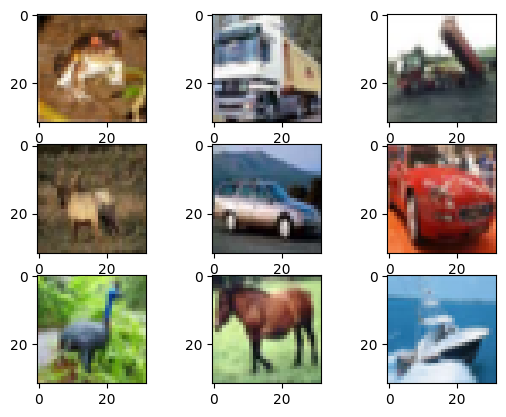

In [1]:
# example of loading the cifar10 dataset
from matplotlib import pyplot
from keras.datasets import cifar10
# load dataset
(trainX, trainy), (testX, testy) = cifar10.load_data()
# summarize loaded dataset
print('Train: X=%s, y=%s' % (trainX.shape, trainy.shape))
print('Test: X=%s, y=%s' % (testX.shape, testy.shape))
# plot first few images
for i in range(9):
	# define subplot
	pyplot.subplot(330 + 1 + i)
	# plot raw pixel data
	pyplot.imshow(trainX[i])
# show the figure
pyplot.show()

Running the example loads the CIFAR-10 train and test dataset and prints their shape.

We can see that there are 50,000 examples in the training dataset and 10,000 in the test dataset and that images are indeed square with 32×32 pixels and color, with three channels.

A plot of the first nine images in the dataset is also created. It is clear that the images are indeed very small compared to modern photographs; it can be challenging to see what exactly is represented in some of the images given the extremely low resolution.

This low resolution is likely the cause of the limited performance that top-of-the-line algorithms are able to achieve on the dataset.

Model Evaluation Test Harness

The CIFAR-10 dataset can be a useful starting point for developing and practicing a methodology for solving image classification problems using convolutional neural networks.

Instead of reviewing the literature on well-performing models on the dataset, we can develop a new model from scratch.

The dataset already has a well-defined train and test dataset that we will use.

The design of the test harness is modular, and we can develop a separate function for each piece. This allows a given aspect of the test harness to be modified or interchanged, if we desire, separately from the rest.

We can develop this test harness with five key elements. They are the loading of the dataset, the preparation of the dataset, the definition of the model, the evaluation of the model, and the presentation of results.

Load Dataset

We know some things about the dataset. For example, we know that the images are all pre-segmented (e.g. each image contains a single object), that the images all have the same square size of 32×32 pixels, and that the images are color. Therefore, we can load the images and use them for modeling almost immediately.

In [2]:
# load dataset
(trainX, trainY), (testX, testY) = cifar10.load_data()

We also know that there are 10 classes and that classes are represented as unique integers.

We can, therefore, use a one hot encoding for the class element of each sample, transforming the integer into a 10 element binary vector with a 1 for the index of the class value. We can achieve this with the to_categorical() utility function.

In [3]:
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from tensorflow.keras.optimizers import SGD
from keras.regularizers import l2

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
# one hot encode target values
trainY = to_categorical(trainY)
testY = to_categorical(testY)

The load_dataset() function implements these behaviors and can be used to load the dataset.

In [4]:
def load_dataset():
	# load dataset
	(trainX, trainY), (testX, testY) = cifar10.load_data()
	# one hot encode target values
	trainY = to_categorical(trainY)
	testY = to_categorical(testY)
	return trainX, trainY, testX, testY

Prepare Pixel Data

We know that the pixel values for each image in the dataset are unsigned integers in the range between no color and full color, or 0 and 255.

We do not know the best way to scale the pixel values for modeling, but we know that some scaling will be required.

A good starting point is to normalize the pixel values, e.g. rescale them to the range [0,1]. This involves first converting the data type from unsigned integers to floats, then dividing the pixel values by the maximum value.

The prep_pixels() function below implement these behaviors and is provided with the pixel values for both the train and test datasets that will need to be scaled.

In [5]:
# scale pixels
def prep_pixels(train, test):
	# convert from integers to floats
	train_norm = train.astype('float32')
	test_norm = test.astype('float32')
	# normalize to range 0-1
	train_norm = train_norm / 255.0
	test_norm = test_norm / 255.0
	# return normalized images
	return train_norm, test_norm

This function must be called to prepare the pixel values prior to any modeling.

Define Model

Next, we need a way to define a neural network model. This is where the concept of a CNN (Convolutional Neural Network) enters the picture. We will start with taking a look at the basic ideas.

What is a CNN?

Convolutional Neural Networks (CNNs) are Artificial Intelligence algorithms based on multi-layer neural networks that learns relevant features from images, being capable of performing several tasks like
object classification, detection, and segmentation.

https://developer.ibm.com/articles/introduction-to-convolutional-neural-networks/

![image.png](attachment:image.png)

The modern concept of Convolutional Neural Networks comes from the work of Yann LeCun published in 1998. LeCun proposed a CNN called LeNet for hand-writing recognition. In 2012, Alex Krizhevsky won the ImageNet Large Scale Visual Recognition Challenge with a CNN model called AlexNet. Krizhevsky used GPUs to train the AlexNet, which enabled faster training of CNNs models and started a wave of interest and new works based on CNNs.

The advantage of CNNs over others classification algorithms (SVM, K-NN, Random-Forest, and others) is that the CNNs learns the best features to represent the objects in the images and has a high generalization capacity, being able to precisely classify new examples with just a few examples in the training set.

A CNN is topically composed by four types of layers:
 - Convolutional
 - Pooling
 - Relu
 - Fully Connected

Convolutional layer

A convolutional layer is composed by a set of filters, also called kernels, that slides over the input data. Each kernel has a width, a height and a number of weights (width * height) utilized to extract features from the input data. In the training step, the weights in the kernel starts with random values, and will be learning based on the training set.

![image-2.png](attachment:image-2.png)

Example of convolution with 1 channel: https://miro.medium.com/max/658/1*GcI7G-JLAQiEoCON7xFbhg.gif
Example of convolution with 3 channels: https://miro.medium.com/max/1600/1*ciDgQEjViWLnCbmX-EeSrA.gif

Each filter in the convolutional layer represents a feature.

![image-3.png](attachment:image-3.png)

When the filter slides over the image and finds a match...

![image-4.png](attachment:image-4.png)

The convolution operation generates a large number, activating the filter to that characteristic.

![image-5.png](attachment:image-5.png)

When the filter slides over the image and finds no match, the filter does not activate. The CNN uses this process to learn the best filters to describe the objects.

![image-6.png](attachment:image-6.png)

![image-7.png](attachment:image-7.png)

The Rectified Linear Units (ReLU)

The ReLU (Rectified Linear Units) layers, is an activation layer linked after a convolutional layer to generate non-linearity in the network. The ReLu helps the network to learn harder decision functions and reduce the overfitting. The ReLu applies the function $y = \max(x,0)$.

![image-8.png](attachment:image-8.png)

Pooling

![image-9.png](attachment:image-9.png)

The pooling layer, or down-sampling layer, is applied to reduce the dimensionality of the feature maps in a way to save the most relevant information from the feature maps. In the pooling layer, a filter slides over the input data and applies the pooling operation (max, min, avg). The max pooling is the most used in the literature.

https://developers.google.com/machine-learning/practica/image-classification/images/maxpool_animation.gif

Fully connected Layer

A CNN is topically divided into two parts: the convolutional and the dense steps. The former learns the best features to extract from the images and the latter learns how to classify the features in different categories.

![image-10.png](attachment:image-10.png)

The Fully Connected layer is a MultiLayer Perceptron (MLP), composed by three types of layers: input, hidden, and output layers.

![image-11.png](attachment:image-11.png)

The input layer receives the features generated by the CNN .

The hidden layer is a sequence of neurons with weights that will be learned in the training step. A MLP is composed by one or more hidden layers.

The output layer is also a sequence of neurons. However, it has a different activation function. Usually, the softmax function (https://deepai.org/machine-learning-glossary-and-terms/softmax-layer) is used to generate the probabilities of each category in the problem scope.

Each neuron is composed by:

- An input vector $\left( x_0 \ x_1 \ \cdots \ x_n \right)$ representing the features

- A weight vector $\left( w_0 \ w_1 \ \cdots \ w_n \right)$ the elements of which will be computed during training

- The bias

- An activation function

- The output

![image-12.png](attachment:image-12.png)

The Perceptron performs the following operation:

$$\mathrm{output} = \mathrm{ActivationFunction} \left( \sum_{k=0}^{n} w_k x_k + \mathrm{bias} \right)$$

The most common activation functions used in the literature are: ReLu, Sigmoid, Softmax, Tanh, Hardlim

Training

- In order to train a CNN model, a training dataset composed by a set of images and labels (classes, bounding boxes, masks) is used.

- The algorithm used to train a CNN is called back-propagation and uses the output value of the last layer to measure an error value. This error value is used to update the weights of each neuron in that layer.

- The new weights are used to measure an error value and update the weights of the previous layer.

- The algorithm repeats the process until it reaches the first layer.

![image-13.png](attachment:image-13.png)

A CNN visualization: https://www.youtube.com/watch?v=JboZfxUjLSk

Popular CNNs for classification tasks
- VGG-16
- ResNets
- Inception

![image-14.png](attachment:image-14.png)

In our notebook computation, we will try modeling a VGG-network. Let's have a look at the VGG-16:

![image-15.png](attachment:image-15.png)

- The VGG-16 was molded with stacks of convolutional layers with small kernels of size 3x3 instead of one convolutional layer with large kernels of size 7x7 and 11x11 in the previously reported architectures LeNet and AlexNet.

- A stack of convolutional layers with small filters sizes generates a decision function more discriminatory by increasing the number of non-linear rectification layers.

- VGG16 layers: https://miro.medium.com/max/480/1*SPHdUMphNbJ9khi5Tg6fIw.png

Model definition - We keep it simple - one VGG-block

The define_model() function below will define and return this model and can be filled-in or replaced for a given model configuration that we wish to evaluate later.

In [6]:
# define cnn model
def define_model():
	model = Sequential()
	model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(32, 32, 3)))
	model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
	model.add(MaxPooling2D((2, 2)))
	model.add(Flatten())
	model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
	model.add(Dense(10, activation='softmax'))
	# compile model
	opt = SGD(lr=0.001, momentum=0.9)
	model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
	return model

Evaluating the model

After the model is defined, we need to fit and evaluate it.

Fitting the model will require that the number of training epochs and batch size to be specified. We will start with using just 1 training epoch (this means that the training data set will be traversed just once), due to the fact that training CNN is computationally intensive and requires long CPU-times. Moreover, we use a modest batch size of 64.

It would be better to use a separate validation dataset, e.g. by splitting the train dataset into train and validation sets. We will not split the data in this case, and instead use the test dataset as a validation dataset to keep the example simple.

The test dataset can be used like a validation dataset and evaluated at the end of each training epoch. This will result in a trace of model evaluation scores on the train and test dataset each epoch that can be plotted later.

In [7]:
# fit model
# history = model.fit(trainX, trainY, epochs=1, batch_size=64, validation_data=(testX, testY), verbose=0)

Once the model is fit, we can evaluate it directly on the test dataset.

In [8]:
# evaluate model
# _, acc = model.evaluate(testX, testY, verbose=0)

Present Results

Once the model has been evaluated, we can present the results.

There are two key aspects to present: the diagnostics of the learning behavior of the model during training and the estimation of the model performance.

First, the diagnostics involve creating a line plot showing model performance on the train and test set during training. These plots are valuable for getting an idea of whether a model is overfitting, underfitting, or has a good fit for the dataset.

We will create a single figure with two subplots, one for loss and one for accuracy. The blue lines will indicate model performance on the training dataset and orange lines will indicate performance on the hold out test dataset. The summarize_diagnostics() function below creates and shows this plot given the collected training histories. The plot is saved to file, specifically a file with the same name as the script with a ‘png‘ extension.

In [9]:
# plot diagnostic learning curves
def summarize_diagnostics(history):
	# plot loss
	pyplot.subplot(211)
	pyplot.title('Cross Entropy Loss')
	pyplot.plot(history.history['loss'], color='blue', label='train')
	pyplot.plot(history.history['val_loss'], color='orange', label='test')
	# plot accuracy
	pyplot.subplot(212)
	pyplot.title('Classification Accuracy')
	pyplot.plot(history.history['accuracy'], color='blue', label='train')
	pyplot.plot(history.history['val_accuracy'], color='orange', label='test')
	# save plot to file
	filename = sys.argv[0].split('/')[-1]
	pyplot.savefig(filename + '_plot.png')
	pyplot.close()

Next, we can report the final model performance on the test dataset.

This can be achieved by printing the classification accuracy directly.

In [10]:
# run the test harness for evaluating a model
def run_test_harness():
	# load dataset
	trainX, trainY, testX, testY = load_dataset()
	# prepare pixel data
	trainX, testX = prep_pixels(trainX, testX)
	# define model
	model = define_model()
	# fit model
	history = model.fit(trainX, trainY, epochs=100, batch_size=64, validation_data=(testX, testY), verbose=0)
	# evaluate model
	_, acc = model.evaluate(testX, testY, verbose=0)
	print('> %.3f' % (acc * 100.0))
	# learning curves
	summarize_diagnostics(history)

Finally, we collect the code sections into one example and run our code:

In [11]:
# baseline model with weight decay on the cifar10 dataset
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from tensorflow.keras.optimizers import SGD
from keras.regularizers import l2

# load train and test dataset
def load_dataset():
	# load dataset
	(trainX, trainY), (testX, testY) = cifar10.load_data()
	# one hot encode target values
	trainY = to_categorical(trainY)
	testY = to_categorical(testY)
	return trainX, trainY, testX, testY

# scale pixels
def prep_pixels(train, test):
	# convert from integers to floats
	train_norm = train.astype('float32')
	test_norm = test.astype('float32')
	# normalize to range 0-1
	train_norm = train_norm / 255.0
	test_norm = test_norm / 255.0
	# return normalized images
	return train_norm, test_norm

# define cnn model
def define_model():
	model = Sequential()
	model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(32, 32, 3)))
	model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
	model.add(MaxPooling2D((2, 2)))
	model.add(Flatten())
	model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
	model.add(Dense(10, activation='softmax'))
	# compile model
	opt = SGD(lr=0.001, momentum=0.9)
	model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
	return model

# plot diagnostic learning curves
def summarize_diagnostics(history):
	# plot loss
	pyplot.subplot(211)
	pyplot.title('Cross Entropy Loss')
	pyplot.plot(history.history['loss'], color='blue', label='train')
	pyplot.plot(history.history['val_loss'], color='orange', label='test')
	# plot accuracy
	pyplot.subplot(212)
	pyplot.title('Classification Accuracy')
	pyplot.plot(history.history['accuracy'], color='blue', label='train')
	pyplot.plot(history.history['val_accuracy'], color='orange', label='test')
	# save plot to file
	filename = sys.argv[0].split('/')[-1]
	pyplot.savefig(filename + '_plot.png')
	pyplot.close()

# run the test harness for evaluating a model
def run_test_harness():
	# load dataset
	trainX, trainY, testX, testY = load_dataset()
	# prepare pixel data
	trainX, testX = prep_pixels(trainX, testX)
	# define model
	model = define_model()
	# fit model
	history = model.fit(trainX, trainY, epochs=3, batch_size=64, validation_data=(testX, testY), verbose=0)
	# evaluate model
	_, acc = model.evaluate(testX, testY, verbose=0)
	print('> %.3f' % (acc * 100.0))
	# learning curves
	summarize_diagnostics(history)

# entry point, run the test harness
run_test_harness()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Argument(s) not recognized: {'lr': 0.001}

Running the model in the test harness first prints the classification accuracy on the test dataset.

Note: Your results may vary given the stochastic nature of the algorithm or evaluation procedure, or differences in numerical precision. Consider running the example a few times and compare the average outcome.

In this case, we can see that the model achieved a classification accuracy of just less than 55%. This was expected, since the single VGG block has insufficient model complexity. However, as the running time of more sophisticated models increase rapidly, we settle for this as a principal example.

A figure is created and saved to file showing the learning curves of the model during training on the train and test dataset, both with regards to the loss and accuracy.

![image.png](attachment:image.png)